# 03 — Multiclass feature selection and model development

## Purpose of this notebook

The main prediction target is the three-class result $Z_i\in\{H,D,A\}$. This notebook selects variables and tunes algorithms using only the development seasons 2021/22–2023/24. The 2024/25 walk-forward outcomes are not loaded into the development sample and cannot influence any decision.

Twelve final branches are required:

- five separate leagues and one pooled comparison;
- a structural/day-before branch and a market/closing-market branch for every scope.

Every branch applies the same transparent sequence: data-quality screening, a football-informed mandatory core, Spearman redundancy control, shadow-feature relevance, recursive feature elimination (RFE), chronological comparison of subset sizes, and compact hyperparameter tuning of ten algorithms. Exact winning features and hyperparameters are printed at the end.

## 1. Chronological development design

Random cross-validation would allow later football states to help evaluate earlier ones. The project instead uses two expanding folds:

| Fold | Training seasons | Validation season | Weight |
|---|---|---|---:|
| 1 | 2021/22 | 2022/23 | 40% |
| 2 | 2021/22–2022/23 | 2023/24 | 60% |

The newer fold receives more weight because it is closer to the final 2024/25 environment, while the older fold remains visible as a stability check. For metric $M$, the combined value is

$$
\bar M=0.4M_1+0.6M_2,
$$

where $M_1$ and $M_2$ are the fold-specific values. Feature screening, imputation, scaling, shadow variables, RFE, and classifier fitting are repeated using each training part only.

## 2. Setup and development-only data

Notebook 02 supplies the candidate table and the structural/market information sets. This notebook immediately removes `walk_forward_test` rows from its working frame. The source lineage remains Understat, ClubElo, dated SoFIFA, and Football-Data, with the cut-offs described in Notebooks 01 and 02.

In [1]:
from pathlib import Path
import os
import sys
import tempfile
import warnings

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "match_prediction_matplotlib"))
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(max(1, os.cpu_count() or 1)))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.classification import MODEL_GRIDS, MODEL_LABELS, make_classifier, make_preprocessor, ordered_probabilities
from src.config import PROCESSED_DATA_DIR, RANDOM_STATE
from src.evaluation import evaluate_multiclass
from src.feature_engineering import get_feature_sets
from src.feature_selection import (
    initial_feature_screen,
    rfe_relevance_ranking,
    shadow_feature_relevance,
    spearman_redundancy_filter,
    summarize_selection_stability,
)
from src.validation import development_folds, summarize_folds, weighted_metric_summary

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 3200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 110)

features = pd.read_csv(PROCESSED_DATA_DIR / "match_features.csv", parse_dates=["date"])
development = features.loc[features["sample_role"].eq("development")].copy()
development = development.sort_values(["date", "league_id", "game_id"]).reset_index(drop=True)
feature_sets = get_feature_sets(development)

LEAGUES = {
    "EPL": "Premier League",
    "LALIGA": "La Liga",
    "BUNDESLIGA": "Bundesliga",
    "SERIE_A": "Serie A",
    "LIGUE_1": "Ligue 1",
}
SCOPES = [(code, name) for code, name in LEAGUES.items()] + [("POOLED", "Pooled five-league model")]
TARGET_ORDER = np.array(["H", "D", "A"])

print(f"Development matches: {len(development):,}")
print(f"Development seasons: {sorted(development['season_id'].unique())}")
print(f"Final-test rows in working data: {development['sample_role'].eq('walk_forward_test').sum()}")

Development matches: 5,404
Development seasons: [np.int64(2021), np.int64(2022), np.int64(2023)]
Final-test rows in working data: 0


The final line must equal zero. The next table verifies fold boundaries and sample sizes for the pooled development sample; each league uses the same season boundaries with its own match counts.

In [2]:
pooled_folds = development_folds(development)
fold_table = summarize_folds(development, pooled_folds)
fold_table["train_seasons"] = ["2021/22", "2021/22–2022/23"]
fold_table["validation_season"] = ["2022/23", "2023/24"]
fold_table.style.format({"weight": "{:.0%}", "train_matches": "{:,}", "validation_matches": "{:,}"})

,fold,weight,train_seasons,validation_season,train_matches,validation_matches,last_train_date,first_validation_date
0,1,40%,2021/22,2022/23,"1,826","1,826",2022-05-22 00:00:00,2022-08-05 00:00:00
1,2,60%,2021/22–2022/23,2023/24,"3,652","1,752",2023-06-04 00:00:00,2023-08-11 00:00:00


## 3. Selection methodology

### 3.1 Data-quality screen

A candidate is rejected when more than 40% of its training values are missing, it has no variation, or one observed value represents at least 99.5% of the training sample. These thresholds are deliberately simple and are applied separately in every fold. Mandatory variables are retained unless they are completely unobserved.

### 3.2 Mandatory football core

Purely automatic selection may discard a stable variable when a correlated substitute happens to rank slightly higher in one season. A small common core therefore represents concepts required in every branch: relative result strength, external rating, squad strength, xG form, points form, rest, and promoted-team context. The market core additionally contains two independent normalised probabilities, the overround sum, and availability.

Because $p_H^M+p_D^M+p_A^M=1$, `market_prob_away` is excluded from fitted candidates when the other two probabilities are present. Its probability remains available for the direct market baseline.

### 3.3 Spearman redundancy

For numerical variables $X$ and $Y$, Spearman's coefficient is the Pearson correlation of their ranks:

$$
\rho_S=\operatorname{corr}(\operatorname{rank}(X),\operatorname{rank}(Y)).
$$

When $|\rho_S|\geq0.92$, the later non-mandatory variable is removed. The ordering favours lower missingness. Rank correlation is suitable because related rolling summaries can have a monotone but not perfectly linear relationship.

### 3.4 Shadow-feature relevance

The shadow procedure follows the idea of Boruta (Kursa and Rudnicki, 2010). Every real candidate $X_j$ receives a permuted copy $X_j^{\mathrm{shadow}}$ that preserves its marginal distribution but destroys its relationship with the target. In six random-forest repetitions, a real variable records a hit when

$$
I_j^{(b)}>\max_k I_{k,\mathrm{shadow}}^{(b)},
$$

where $I^{(b)}$ is impurity-based importance in repetition $b$. A hit rate of at least 60% is `confirmed`; at least 34% is `tentative`. Both proceed to RFE. If fewer than four variables reach these thresholds, the strongest shadow-ranked variables complete a minimum four-variable supplement so that subset comparison remains possible; this fallback is reported explicitly.

### 3.5 Recursive feature elimination

RFE repeatedly fits a scaled multinomial logistic model and removes the weakest coefficients from the already reduced supplement. It is not run blindly on all original candidates. Three sizes are compared: up to 4, 8, and 16 supplementary variables in addition to the available mandatory core. The size is selected by chronological validation, not training fit.

References: Kursa, M. B. and Rudnicki, W. R. (2010), *Feature Selection with the Boruta Package*, Journal of Statistical Software 36(11); Guyon et al. (2002), *Gene Selection for Cancer Classification using Support Vector Machines*, Machine Learning 46.

## 4. Candidate sets and mandatory core

The pooled models include `league_id`, which is one-hot encoded inside each fitted pipeline. Separate league models do not need this variable. No match identifier, team name, current score, current xG, or target is present in the candidate sets.

In [3]:
CORE_STRUCTURAL = [
    "elo_diff_pre",
    "clubelo_diff",
    "clubelo_available",
    "diff_sofifa_top11_overall",
    "sofifa_available",
    "diff_xg_diff_ewm_span_5",
    "diff_points_mean_last_5",
    "diff_rest_days",
    "home_promoted_or_returning",
    "away_promoted_or_returning",
]
CORE_MARKET = CORE_STRUCTURAL + [
    "market_prob_home",
    "market_prob_draw",
    "market_overround",
    "market_available",
]

BASE_CANDIDATES = {
    "structural": [feature for feature in feature_sets["structural_full"] if feature != "league_id"],
    "market": [feature for feature in feature_sets["market_full"] if feature not in {"league_id", "market_prob_away"}],
}

candidate_overview = pd.DataFrame(
    [
        {"branch": branch, "raw_candidates_separate_league": len(candidates), "mandatory_core": len(CORE_STRUCTURAL if branch == "structural" else CORE_MARKET), "pooled_addition": "league_id"}
        for branch, candidates in BASE_CANDIDATES.items()
    ]
)
candidate_overview

,branch,raw_candidates_separate_league,mandatory_core,pooled_addition
0,structural,228,10,league_id
1,market,232,14,league_id


The structural branch begins with 228 numerical candidates per separate league; the market branch adds four fitted market variables. The screen and selection are not shared across leagues because relevance and redundancy can differ by competition.

## 5. Fold-wise selection implementation

The next cell is the direct implementation of the five stages. It returns the three candidate subset levels and a feature-by-feature audit. Only the supplied training frame is visible to the function.

In [4]:
SUBSET_LIMITS = {"compact": 4, "standard": 8, "full_relevant": 16}


def scope_data(scope_code: str) -> pd.DataFrame:
    if scope_code == "POOLED":
        return development.copy()
    return development.loc[development["league_id"].eq(scope_code)].copy()


def branch_definition(scope_code: str, branch: str) -> tuple[list[str], list[str]]:
    candidates = list(BASE_CANDIDATES[branch])
    mandatory = list(CORE_STRUCTURAL if branch == "structural" else CORE_MARKET)
    if scope_code == "POOLED":
        candidates = ["league_id"] + candidates
        mandatory = ["league_id"] + mandatory
    return candidates, mandatory


def select_training_features(train: pd.DataFrame, scope_code: str, branch: str):
    candidates, mandatory = branch_definition(scope_code, branch)
    screened, screen_audit = initial_feature_screen(
        train, candidates, mandatory, missing_threshold=0.40, dominant_threshold=0.995
    )
    available_mandatory = [feature for feature in mandatory if feature in screened]
    decorrelated, correlation_audit = spearman_redundancy_filter(
        train, screened, available_mandatory, threshold=0.92
    )
    supplement = [feature for feature in decorrelated if feature not in available_mandatory]
    shadow_selected, shadow_audit = shadow_feature_relevance(
        train, train["target_1x2"], supplement, iterations=6, n_estimators=180
    )
    fallback_features = []
    if len(shadow_selected) < 4:
        fallback_features = [
            feature for feature in shadow_audit["feature"]
            if feature not in shadow_selected
        ][: 4 - len(shadow_selected)]
    rfe_pool = list(dict.fromkeys(shadow_selected + fallback_features))
    rfe = rfe_relevance_ranking(train, train["target_1x2"], rfe_pool)
    importance = shadow_audit.set_index("feature")["mean_importance"].to_dict()
    ranked = sorted(
        rfe_pool,
        key=lambda feature: (
            int(rfe.set_index("feature").loc[feature, "rfe_rank"]),
            -importance.get(feature, 0.0),
            feature,
        ),
    )
    feature_lists = {
        level: list(dict.fromkeys(available_mandatory + ranked[: min(limit, len(ranked))]))
        for level, limit in SUBSET_LIMITS.items()
    }
    return {
        "feature_lists": feature_lists,
        "mandatory": available_mandatory,
        "ranked_supplement": ranked,
        "fallback": fallback_features,
        "screen_audit": screen_audit,
        "correlation_audit": correlation_audit,
        "shadow_audit": shadow_audit,
        "rfe_audit": rfe,
    }


def logistic_probabilities(train: pd.DataFrame, validation: pd.DataFrame, columns: list[str]) -> np.ndarray:
    pipeline = Pipeline(
        [
            ("preprocessor", make_preprocessor(columns)),
            ("classifier", LogisticRegression(C=0.1, max_iter=2500, random_state=RANDOM_STATE)),
        ]
    )
    pipeline.fit(train[columns], train["target_1x2"])
    transformed = pipeline.named_steps["preprocessor"].transform(validation[columns])
    return ordered_probabilities(pipeline.named_steps["classifier"], transformed, TARGET_ORDER)

### 5.1 Run selection and compare supplement sizes

The regularised multinomial logistic model is used only as a common measuring instrument for subset size. It does not predetermine the winning algorithm. The loop evaluates all scopes, both information branches, both folds, and all three subset levels.

In [5]:
selection_objects = {}
selection_rows = []

for scope_code, scope_name in SCOPES:
    data = scope_data(scope_code)
    for branch in ["structural", "market"]:
        for fold in development_folds(data):
            train = data.loc[fold["train_index"]]
            validation = data.loc[fold["validation_index"]]
            selection = select_training_features(train, scope_code, branch)
            selection_objects[(scope_code, branch, fold["fold"])] = selection
            for level, columns in selection["feature_lists"].items():
                probabilities = logistic_probabilities(train, validation, columns)
                metrics = evaluate_multiclass(validation["target_1x2"], probabilities)
                selection_rows.append(
                    {
                        "scope_code": scope_code,
                        "scope": scope_name,
                        "branch": branch,
                        "fold": fold["fold"],
                        "weight": fold["weight"],
                        "validation_season": fold["validation_season"],
                        "subset_level": level,
                        "input_features": len(columns),
                        "supplement_features": len(columns) - len(selection["mandatory"]),
                        **metrics,
                    }
                )

selection_fold_results = pd.DataFrame(selection_rows)
selection_summary = weighted_metric_summary(
    selection_fold_results,
    metric_columns=["accuracy", "macro_f1", "draw_recall", "log_loss", "brier_score"],
    group_columns=["scope_code", "scope", "branch", "subset_level"],
)
selection_summary.sort_values(["scope", "branch", "accuracy"], ascending=[True, True, False]).style.format(
    {"accuracy": "{:.2%}", "macro_f1": "{:.2%}", "draw_recall": "{:.2%}", "log_loss": "{:.4f}", "brier_score": "{:.4f}"}
)

,scope_code,scope,branch,subset_level,folds,accuracy,macro_f1,draw_recall,log_loss,brier_score
0,BUNDESLIGA,Bundesliga,market,compact,2,52.94%,42.24%,6.28%,0.9862,0.5854
2,BUNDESLIGA,Bundesliga,market,standard,2,52.16%,41.76%,6.28%,0.9910,0.5887
1,BUNDESLIGA,Bundesliga,market,full_relevant,2,50.78%,40.53%,6.28%,0.9976,0.5934
3,BUNDESLIGA,Bundesliga,structural,compact,2,51.37%,39.01%,2.13%,0.9945,0.5917
5,BUNDESLIGA,Bundesliga,structural,standard,2,50.20%,38.03%,2.13%,0.9998,0.5954
4,BUNDESLIGA,Bundesliga,structural,full_relevant,2,49.61%,38.10%,2.87%,1.0064,0.6001
12,LALIGA,La Liga,market,compact,2,50.89%,40.43%,7.64%,1.0009,0.5950
14,LALIGA,La Liga,market,standard,2,50.74%,40.04%,7.19%,1.0052,0.5980
13,LALIGA,La Liga,market,full_relevant,2,50.11%,39.88%,7.19%,1.0079,0.5999
15,LALIGA,La Liga,structural,compact,2,51.68%,39.99%,5.62%,1.0058,0.5983


Each row is a weighted combination of two genuinely future-season validations. The feature count can differ slightly between folds because a mandatory variable may be completely unavailable or the shadow procedure may retain fewer supplements.

### 5.2 Choose subset level

Accuracy is primary. Levels within 0.5 percentage points of the best accuracy are considered practically similar; among them, lower log-loss, lower Brier score, and the smaller nominal subset are preferred.

In [6]:
LEVEL_ORDER = {"compact": 0, "standard": 1, "full_relevant": 2}


def choose_rows_with_tolerance(summary: pd.DataFrame, groups: list[str]) -> pd.DataFrame:
    winners = []
    for _, group in summary.groupby(groups, sort=True):
        best_accuracy = group["accuracy"].max()
        comparable = group.loc[group["accuracy"].ge(best_accuracy - 0.005)].copy()
        comparable["simplicity_order"] = comparable.get("subset_level", pd.Series(index=comparable.index, dtype="object")).map(LEVEL_ORDER).fillna(0)
        winner = comparable.sort_values(
            ["log_loss", "brier_score", "simplicity_order"], ascending=[True, True, True]
        ).iloc[0].to_dict()
        winner["best_accuracy"] = best_accuracy
        winner["equivalent_candidates"] = len(comparable)
        winners.append(winner)
    return pd.DataFrame(winners)


selected_designs = choose_rows_with_tolerance(selection_summary, ["scope_code", "scope", "branch"])
selected_designs[
    ["scope_code", "scope", "branch", "subset_level", "accuracy", "log_loss", "brier_score", "best_accuracy", "equivalent_candidates"]
].sort_values(["scope", "branch"]).style.format(
    {"accuracy": "{:.2%}", "best_accuracy": "{:.2%}", "log_loss": "{:.4f}", "brier_score": "{:.4f}"}
)

,scope_code,scope,branch,subset_level,accuracy,log_loss,brier_score,best_accuracy,equivalent_candidates
0,BUNDESLIGA,Bundesliga,market,compact,52.94%,0.9862,0.5854,52.94%,1
1,BUNDESLIGA,Bundesliga,structural,compact,51.37%,0.9945,0.5917,51.37%,1
4,LALIGA,La Liga,market,compact,50.89%,1.0009,0.5950,50.89%,2
5,LALIGA,La Liga,structural,compact,51.68%,1.0058,0.5983,51.68%,1
6,LIGUE_1,Ligue 1,market,standard,50.12%,1.0451,0.6203,50.12%,1
7,LIGUE_1,Ligue 1,structural,standard,49.23%,1.0425,0.6216,49.23%,1
8,POOLED,Pooled five-league model,market,compact,53.92%,0.9694,0.5760,53.92%,2
9,POOLED,Pooled five-league model,structural,compact,52.68%,0.9793,0.5834,52.82%,2
2,EPL,Premier League,market,compact,55.89%,0.9748,0.5709,55.89%,1
3,EPL,Premier League,structural,compact,55.53%,0.9831,0.5771,55.53%,1


The chosen level is fixed separately for every league/pooled scope and information branch. A larger set is not rewarded unless its out-of-time probabilities justify the extra complexity.

## 6. Stability across the two development folds

Selection stability is the frequency with which a variable appears in the chosen subset of fold 1 and fold 2. A frequency of 1.0 means both independent training histories selected it; 0.5 means only one did. Mandatory features can be absent in fold 1 when the 2021/22 values are completely missing, which is visible rather than silently overridden.

In [7]:
stability_parts = []
for design in selected_designs.itertuples(index=False):
    selected_by_fold = {
        fold: selection_objects[(design.scope_code, design.branch, fold)]["feature_lists"][design.subset_level]
        for fold in [1, 2]
    }
    stability = summarize_selection_stability(selected_by_fold)
    stability.insert(0, "branch", design.branch)
    stability.insert(0, "scope", design.scope)
    stability_parts.append(stability)

selection_stability = pd.concat(stability_parts, ignore_index=True)
stability_summary = (
    selection_stability.groupby(["scope", "branch"])
    .agg(features_seen=("feature", "size"), stable_features=("selection_frequency", lambda values: (values == 1).sum()), mean_stability=("selection_frequency", "mean"))
    .reset_index()
)
stability_summary.style.format({"mean_stability": "{:.1%}"})

,scope,branch,features_seen,stable_features,mean_stability
0,Bundesliga,market,21,13,81.0%
1,Bundesliga,structural,17,9,76.5%
2,La Liga,market,20,14,85.0%
3,La Liga,structural,16,10,81.2%
4,Ligue 1,market,24,14,79.2%
5,Ligue 1,structural,20,10,75.0%
6,Pooled five-league model,market,21,15,85.7%
7,Pooled five-league model,structural,17,11,82.4%
8,Premier League,market,22,12,77.3%
9,Premier League,structural,18,8,72.2%


Stability is diagnostic, not a third tuning target. Low stability warns that several correlated features may be interchangeable or that one training season is too small to rank them reliably.

## 7. Re-estimate the locked feature sets on all development seasons

After choosing the method and subset size, the selection pipeline is fitted once on 2021/22–2023/24. It still cannot access 2024/25. The combined audit below contains every candidate and the exact stage at which it is retained or rejected.

In [8]:
def feature_metadata(feature: str) -> tuple[str, str, str]:
    if feature == "league_id":
        return "Understat fixture", "One-hot league identity", "Known from schedule"
    if feature.startswith("market_"):
        return "Football-Data", "Normalised inverse odds, overround, or availability", "Archived pre-match/closing price"
    if "clubelo" in feature or "competition_level" in feature:
        return "ClubElo", "Dated rating level, contrast, expectation, or availability", "Valid rating interval on match date"
    if "sofifa" in feature:
        return "Public EA Sports player data", "Dated squad aggregate, contrast, age, or availability", "Latest snapshot not after match date"
    if "elo" in feature:
        return "Calculated from Understat results", "Pre-match internal Elo state", "Before current result update"
    if feature.startswith("league_"):
        return "Calculated from Understat results", "League rate from earlier dates", "Strictly earlier calendar dates"
    if "rest" in feature:
        return "Understat fixture dates", "Rest days, short-rest flag, or contrast", "Known before kick-off"
    if "mean_last" in feature:
        calculation = "Shifted rolling mean of earlier matches"
    elif "ewm_span" in feature:
        calculation = "Shifted exponentially weighted mean"
    elif "season_mean_pre" in feature:
        calculation = "Shifted season-to-date mean"
    elif "venue_mean" in feature:
        calculation = "Shifted venue-specific rolling mean"
    else:
        calculation = "Pre-match history or context variable"
    return "Understat history / project calculation", calculation, "Earlier completed matches only"


final_features = {}
final_audit_parts = []
for design in selected_designs.itertuples(index=False):
    data = scope_data(design.scope_code)
    selection = select_training_features(data, design.scope_code, design.branch)
    chosen = selection["feature_lists"][design.subset_level]
    final_features[(design.scope_code, design.branch)] = chosen
    candidates, mandatory = branch_definition(design.scope_code, design.branch)
    audit = pd.DataFrame({"feature": candidates})
    audit = audit.merge(selection["screen_audit"], on="feature", how="left")
    audit = audit.merge(selection["correlation_audit"], on=["feature", "mandatory"], how="left")
    audit = audit.merge(selection["shadow_audit"], on="feature", how="left")
    audit = audit.merge(selection["rfe_audit"], on="feature", how="left")
    audit["fallback_after_shadow"] = audit["feature"].isin(selection["fallback"])
    audit["final_selected"] = audit["feature"].isin(chosen)
    audit["final_role"] = np.select(
        [
            audit["final_selected"] & audit["feature"].isin(selection["mandatory"]),
            audit["final_selected"],
            audit["screen_retained"].eq(False),
            audit["correlation_retained"].eq(False),
            audit["shadow_status"].eq("rejected"),
        ],
        ["mandatory core", "selected supplement", "rejected in quality screen", "rejected as Spearman-redundant", "rejected by shadow relevance"],
        default="RFE-ranked but outside chosen subset",
    )
    metadata = audit["feature"].map(feature_metadata)
    audit[["source", "calculation", "information_cutoff"]] = pd.DataFrame(metadata.tolist(), index=audit.index)
    audit.insert(0, "branch", design.branch)
    audit.insert(0, "scope", design.scope)
    final_audit_parts.append(audit)

final_selection_audit = pd.concat(final_audit_parts, ignore_index=True)
final_selection_summary = (
    final_selection_audit.groupby(["scope", "branch", "final_role"])
    .size().rename("features").reset_index()
)
final_selection_summary

,scope,branch,final_role,features
0,Bundesliga,market,RFE-ranked but outside chosen subset,21
1,Bundesliga,market,mandatory core,14
2,Bundesliga,market,rejected as Spearman-redundant,71
3,Bundesliga,market,rejected by shadow relevance,120
4,Bundesliga,market,rejected in quality screen,2
5,Bundesliga,market,selected supplement,4
6,Bundesliga,structural,RFE-ranked but outside chosen subset,21
7,Bundesliga,structural,mandatory core,10
8,Bundesliga,structural,rejected as Spearman-redundant,71
9,Bundesliga,structural,rejected by shadow relevance,120


The summary compresses the selection path. The complete candidate-level audit follows. It is long by design: it provides the requested trace from source and calculation to final status without creating a separate manifest file.

In [9]:
final_selection_audit[
    [
        "scope", "branch", "feature", "source", "calculation", "information_cutoff",
        "mandatory", "missing_share", "screen_reason", "correlation_reason",
        "shadow_hit_rate", "shadow_status", "rfe_rank", "fallback_after_shadow",
        "final_selected", "final_role",
    ]
]

,scope,branch,feature,source,calculation,information_cutoff,mandatory,missing_share,screen_reason,correlation_reason,shadow_hit_rate,shadow_status,rfe_rank,fallback_after_shadow,final_selected,final_role
0,Bundesliga,market,home_elo_pre,Calculated from Understat results,Pre-match internal Elo state,Before current result update,False,0.000000,retained,retained,0.000000,rejected,NaN,False,False,rejected by shadow relevance
1,Bundesliga,market,away_elo_pre,Calculated from Understat results,Pre-match internal Elo state,Before current result update,False,0.000000,retained,retained,0.833333,confirmed,12.0,False,False,RFE-ranked but outside chosen subset
2,Bundesliga,market,elo_diff_pre,Calculated from Understat results,Pre-match internal Elo state,Before current result update,True,0.000000,retained,retained,NaN,NaN,NaN,False,True,mandatory core
3,Bundesliga,market,elo_home_expectation,Calculated from Understat results,Pre-match internal Elo state,Before current result update,False,0.000000,retained,spearman_redundant_with:elo_diff_pre,NaN,NaN,NaN,False,False,rejected as Spearman-redundant
4,Bundesliga,market,league_home_win_rate_pre,Calculated from Understat results,League rate from earlier dates,Strictly earlier calendar dates,False,0.001089,retained,retained,0.000000,rejected,NaN,False,False,rejected by shadow relevance
5,Bundesliga,market,league_draw_rate_pre,Calculated from Understat results,League rate from earlier dates,Strictly earlier calendar dates,False,0.001089,retained,retained,0.000000,rejected,NaN,False,False,rejected by shadow relevance
6,Bundesliga,market,league_goals_mean_pre,Calculated from Understat results,League rate from earlier dates,Strictly earlier calendar dates,False,0.001089,retained,retained,0.000000,rejected,NaN,False,False,rejected by shadow relevance
7,Bundesliga,market,home_history_matches_before,Understat history / project calculation,Pre-match history or context variable,Earlier completed matches only,False,0.000000,retained,retained,0.000000,rejected,NaN,False,False,rejected by shadow relevance
8,Bundesliga,market,away_history_matches_before,Understat history / project calculation,Pre-match history or context variable,Earlier completed matches only,False,0.000000,retained,retained,0.000000,rejected,NaN,False,False,rejected by shadow relevance
9,Bundesliga,market,diff_history_matches_before,Understat history / project calculation,Pre-match history or context variable,Earlier completed matches only,False,0.000000,retained,retained,0.000000,rejected,NaN,False,False,rejected by shadow relevance


## 8. Compact reference models

Three transparent references provide context before complex tuning:

1. **training frequency** assigns the training shares of H, D, and A to every validation match;
2. **Elo reference** combines the pre-match internal Elo expectation with the training draw rate;
3. **direct market** uses the normalised Football-Data probabilities without fitting a classifier.

The Poisson reference is developed separately and in full detail in Notebook 04.

In [10]:
baseline_rows = []
for scope_code, scope_name in SCOPES:
    data = scope_data(scope_code)
    for fold in development_folds(data):
        train = data.loc[fold["train_index"]]
        validation = data.loc[fold["validation_index"]]
        frequency = train["target_1x2"].value_counts(normalize=True).reindex(TARGET_ORDER).fillna(0).to_numpy()
        frequency_prob = np.tile(frequency, (len(validation), 1))
        elo_home = validation["elo_home_expectation"].fillna(0.5).clip(0.03, 0.97).to_numpy()
        draw_rate = train["target_1x2"].eq("D").mean()
        elo_prob = np.column_stack([(1 - draw_rate) * elo_home, np.full(len(validation), draw_rate), (1 - draw_rate) * (1 - elo_home)])
        for label, probability, used in [
            ("Training result frequency", frequency_prob, np.ones(len(validation), dtype=bool)),
            ("Internal Elo reference", elo_prob, np.ones(len(validation), dtype=bool)),
            ("Direct market probabilities", validation[["market_prob_home", "market_prob_draw", "market_prob_away"]].to_numpy(), validation["market_available"].eq(1).to_numpy()),
        ]:
            metrics = evaluate_multiclass(validation.loc[used, "target_1x2"], probability[used])
            baseline_rows.append({"scope_code": scope_code, "scope": scope_name, "baseline": label, "fold": fold["fold"], "weight": fold["weight"], "n_matches": int(used.sum()), **metrics})

baseline_fold_results = pd.DataFrame(baseline_rows)
baseline_summary = weighted_metric_summary(
    baseline_fold_results,
    metric_columns=["accuracy", "macro_f1", "draw_recall", "log_loss", "brier_score", "n_matches"],
    group_columns=["scope_code", "scope", "baseline"],
)
baseline_summary.sort_values(["scope", "accuracy"], ascending=[True, False]).style.format(
    {"accuracy": "{:.2%}", "macro_f1": "{:.2%}", "draw_recall": "{:.2%}", "log_loss": "{:.4f}", "brier_score": "{:.4f}", "n_matches": "{:.0f}"}
)

,scope_code,scope,baseline,folds,accuracy,macro_f1,draw_recall,log_loss,brier_score,n_matches
0,BUNDESLIGA,Bundesliga,Direct market probabilities,2,55.49%,41.35%,0.00%,0.9658,0.5729,306
1,BUNDESLIGA,Bundesliga,Internal Elo reference,2,51.63%,36.25%,0.00%,1.0092,0.6041,306
2,BUNDESLIGA,Bundesliga,Training result frequency,2,45.23%,20.76%,0.00%,1.0681,0.6455,306
6,LALIGA,La Liga,Direct market probabilities,2,55.09%,41.31%,0.57%,0.9604,0.5713,379
7,LALIGA,La Liga,Internal Elo reference,2,51.00%,35.39%,0.00%,1.0018,0.5990,380
8,LALIGA,La Liga,Training result frequency,2,45.53%,20.85%,0.00%,1.0690,0.6458,380
9,LIGUE_1,Ligue 1,Direct market probabilities,2,52.85%,39.66%,0.00%,0.9949,0.5956,334
10,LIGUE_1,Ligue 1,Internal Elo reference,2,48.36%,33.94%,0.00%,1.0336,0.6210,336
11,LIGUE_1,Ligue 1,Training result frequency,2,40.69%,19.27%,0.00%,1.0830,0.6564,336
12,POOLED,Pooled five-league model,Direct market probabilities,2,55.19%,41.38%,0.13%,0.9618,0.5716,1778


## 9. Algorithms and evaluation criteria

Ten classifier families are retained so that linear, local, probabilistic, tree-based, and boosting assumptions are compared rather than assumed:

| Family | Main idea | Main tuned complexity |
|---|---|---|
| Multinomial logistic regression | linear log-odds | regularisation $C$ |
| Decision tree | recursive nonlinear partitions | depth and leaf size |
| Random forest | average of randomised trees | depth and leaf size |
| Calibrated linear SVM | maximum-margin separation plus sigmoid calibration | $C$ |
| kNN | local class composition among nearby scaled matches | neighbours and weighting |
| Gaussian naive Bayes | class-conditional Gaussian marginals | variance smoothing |
| Gradient boosting | sequential correction by shallow trees | trees, learning rate, depth |
| XGBoost | regularised stochastic tree boosting | trees, rate, depth, child weight |
| LightGBM | leaf-wise histogram boosting | trees, rate, leaves, child size |
| CatBoost | ordered boosting with strong regularisation | iterations, rate, depth, L2 |

The key tree/boosting references are Breiman (2001), Friedman (2001), Chen and Guestrin (2016), Ke et al. (2017), and Prokhorenkova et al. (2018).

Accuracy is primary:

$$
\mathrm{Accuracy}=\frac{1}{N}\sum_{i=1}^{N}\mathbb{1}(\widehat Z_i=Z_i).
$$

For probability quality, multiclass log-loss and Brier score are

$$
\mathrm{LogLoss}=-\frac{1}{N}\sum_{i=1}^{N}\sum_{k\in\{H,D,A\}}y_{ik}\log p_{ik},
$$

$$
\mathrm{Brier}=\frac{1}{N}\sum_{i=1}^{N}\sum_{k\in\{H,D,A\}}(p_{ik}-y_{ik})^2.
$$

Here $p_{ik}$ is the predicted probability and $y_{ik}$ the one-hot observed class. Macro F1 gives equal class importance; draw recall reports the share of actual draws predicted as draws. Models within 0.5 percentage points of the best accuracy are treated as practically similar, after which lower log-loss, lower Brier score, and simplicity decide.

## 10. Compact hyperparameter tuning

Every preprocessing step is fitted on the training portion: median imputation, missingness indicators, standardisation, and pooled league encoding. The grids examine interpretable changes in regularisation or complexity rather than an opaque large search. Fold-specific selected features are reused, so a validation season never ranks its own inputs.

In [11]:
def model_probabilities(train, validation, columns, model_name, parameters):
    preprocessor = make_preprocessor(columns)
    x_train = preprocessor.fit_transform(train[columns])
    x_validation = preprocessor.transform(validation[columns])
    classifier = make_classifier(model_name, parameters)
    if model_name == "xgboost":
        y_train = pd.Categorical(train["target_1x2"], categories=TARGET_ORDER).codes
        classifier.fit(x_train, y_train)
        return classifier.predict_proba(x_validation)
    classifier.fit(x_train, train["target_1x2"])
    return ordered_probabilities(classifier, x_validation, TARGET_ORDER)


tuning_rows = []
for design in selected_designs.itertuples(index=False):
    data = scope_data(design.scope_code)
    for fold in development_folds(data):
        train = data.loc[fold["train_index"]]
        validation = data.loc[fold["validation_index"]]
        columns = selection_objects[(design.scope_code, design.branch, fold["fold"])]["feature_lists"][design.subset_level]
        for model_name, grid in MODEL_GRIDS.items():
            for parameter_id, parameters in enumerate(grid, start=1):
                probabilities = model_probabilities(train, validation, columns, model_name, parameters)
                metrics = evaluate_multiclass(validation["target_1x2"], probabilities)
                tuning_rows.append(
                    {
                        "scope_code": design.scope_code,
                        "scope": design.scope,
                        "branch": design.branch,
                        "subset_level": design.subset_level,
                        "fold": fold["fold"],
                        "weight": fold["weight"],
                        "model": model_name,
                        "model_label": MODEL_LABELS[model_name],
                        "parameter_id": parameter_id,
                        "parameters": repr(parameters),
                        "input_features": len(columns),
                        **metrics,
                    }
                )

tuning_fold_results = pd.DataFrame(tuning_rows)
tuning_summary = weighted_metric_summary(
    tuning_fold_results,
    metric_columns=["accuracy", "macro_f1", "draw_recall", "log_loss", "brier_score", "input_features"],
    group_columns=["scope_code", "scope", "branch", "subset_level", "model", "model_label", "parameter_id", "parameters"],
)
tuning_summary.sort_values(["scope", "branch", "accuracy"], ascending=[True, True, False]).style.format(
    {"accuracy": "{:.2%}", "macro_f1": "{:.2%}", "draw_recall": "{:.2%}", "log_loss": "{:.4f}", "brier_score": "{:.4f}", "input_features": "{:.1f}"}
)

  File "C:\Users\cerve\Desktop\DP\match_prediction\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,scope_code,scope,branch,subset_level,model,model_label,parameter_id,parameters,folds,accuracy,macro_f1,draw_recall,log_loss,brier_score,input_features
9,BUNDESLIGA,Bundesliga,market,compact,knn,k-nearest neighbours,3,"{'n_neighbors': 100, 'weights': 'distance'}",2,53.40%,39.63%,0.53%,0.9926,0.5933,17.2
12,BUNDESLIGA,Bundesliga,market,compact,logistic,Multinomial logistic regression,1,{'C': 0.01},2,53.33%,39.05%,0.53%,0.9750,0.5809,17.2
21,BUNDESLIGA,Bundesliga,market,compact,svm,Calibrated linear support vector machine,1,{'C': 0.01},2,53.14%,38.36%,0.53%,0.9827,0.5862,17.2
13,BUNDESLIGA,Bundesliga,market,compact,logistic,Multinomial logistic regression,2,{'C': 0.1},2,52.94%,42.24%,6.28%,0.9862,0.5854,17.2
14,BUNDESLIGA,Bundesliga,market,compact,logistic,Multinomial logistic regression,3,{'C': 1.0},2,52.88%,44.52%,12.65%,1.0001,0.5912,17.2
22,BUNDESLIGA,Bundesliga,market,compact,svm,Calibrated linear support vector machine,2,{'C': 0.1},2,52.55%,37.30%,0.53%,0.9903,0.5911,17.2
20,BUNDESLIGA,Bundesliga,market,compact,random_forest,Random forest,3,"{'max_depth': None, 'min_samples_leaf': 10, 'max_features': 'sqrt'}",2,52.35%,43.71%,9.66%,0.9907,0.5918,17.2
18,BUNDESLIGA,Bundesliga,market,compact,random_forest,Random forest,1,"{'max_depth': 8, 'min_samples_leaf': 10, 'max_features': 'sqrt'}",2,52.16%,43.96%,11.14%,0.9912,0.5917,17.2
23,BUNDESLIGA,Bundesliga,market,compact,svm,Calibrated linear support vector machine,3,{'C': 1.0},2,51.96%,35.89%,0.53%,0.9934,0.5931,17.2
19,BUNDESLIGA,Bundesliga,market,compact,random_forest,Random forest,2,"{'max_depth': 14, 'min_samples_leaf': 5, 'max_features': 'sqrt'}",2,51.11%,43.29%,12.33%,0.9994,0.5977,17.2


The full table exposes every hyperparameter candidate. Performance must be read together with probability scores: a small accuracy gain can be unattractive when it produces overconfident log-loss or unstable draw behaviour.

## 11. Simple probability ensemble

For each branch, the best validated setting of every algorithm family is identified. The three highest-accuracy families are then averaged with equal weights:

$$
p_{ik}^{\mathrm{ens}}=\frac{1}{3}\sum_{m=1}^{3}p_{ik}^{(m)}.
$$

Equal weighting is transparent and avoids fitting ensemble weights on only two validation seasons. The ensemble is evaluated on the same folds and selected features.

In [12]:
def choose_best_parameter_per_family(summary):
    rows = []
    for _, group in summary.groupby(["scope_code", "scope", "branch", "model", "model_label"], sort=True):
        best_accuracy = group["accuracy"].max()
        comparable = group.loc[group["accuracy"].ge(best_accuracy - 0.005)]
        rows.append(comparable.sort_values(["log_loss", "brier_score", "parameter_id"]).iloc[0].to_dict())
    return pd.DataFrame(rows)


family_winners = choose_best_parameter_per_family(tuning_summary)
ensemble_components = {}
ensemble_rows = []
for design in selected_designs.itertuples(index=False):
    candidates = family_winners.loc[
        family_winners["scope_code"].eq(design.scope_code) & family_winners["branch"].eq(design.branch)
    ].sort_values(["accuracy", "log_loss", "brier_score"], ascending=[False, True, True])
    components = candidates.head(3)
    ensemble_components[(design.scope_code, design.branch)] = components[["model", "model_label", "parameter_id", "parameters"]].to_dict("records")
    data = scope_data(design.scope_code)
    for fold in development_folds(data):
        train = data.loc[fold["train_index"]]
        validation = data.loc[fold["validation_index"]]
        columns = selection_objects[(design.scope_code, design.branch, fold["fold"])]["feature_lists"][design.subset_level]
        predictions = []
        for component in components.itertuples(index=False):
            parameters = MODEL_GRIDS[component.model][int(component.parameter_id) - 1]
            predictions.append(model_probabilities(train, validation, columns, component.model, parameters))
        probability = np.mean(predictions, axis=0)
        metrics = evaluate_multiclass(validation["target_1x2"], probability)
        ensemble_rows.append({"scope_code": design.scope_code, "scope": design.scope, "branch": design.branch, "fold": fold["fold"], "weight": fold["weight"], **metrics})

ensemble_fold_results = pd.DataFrame(ensemble_rows)
ensemble_summary = weighted_metric_summary(
    ensemble_fold_results,
    metric_columns=["accuracy", "macro_f1", "draw_recall", "log_loss", "brier_score"],
    group_columns=["scope_code", "scope", "branch"],
)
ensemble_summary["model"] = "ensemble"
ensemble_summary["model_label"] = "Equal-weight top-three ensemble"
ensemble_summary["parameter_id"] = 1
ensemble_summary["parameters"] = ensemble_summary.apply(lambda row: repr(ensemble_components[(row["scope_code"], row["branch"])]), axis=1)
ensemble_summary = ensemble_summary.merge(selected_designs[["scope_code", "branch", "subset_level"]], on=["scope_code", "branch"], how="left")
ensemble_summary

,scope_code,scope,branch,folds,accuracy,macro_f1,draw_recall,log_loss,brier_score,model,model_label,parameter_id,parameters,subset_level
0,BUNDESLIGA,Bundesliga,market,2,0.539869,0.394406,0.005333,0.980580,0.584871,ensemble,Equal-weight top-three ensemble,1,"[{'model': 'knn', 'model_label': 'k-nearest neighbours', 'parameter_id': 3, 'parameters': ""{'n_neighbors':...",compact
1,BUNDESLIGA,Bundesliga,structural,2,0.529412,0.378210,0.000000,0.988305,0.590238,ensemble,Equal-weight top-three ensemble,1,"[{'model': 'logistic', 'model_label': 'Multinomial logistic regression', 'parameter_id': 1, 'parameters': ...",compact
2,EPL,Premier League,market,2,0.573158,0.421938,0.004598,0.950538,0.560356,ensemble,Equal-weight top-three ensemble,1,"[{'model': 'catboost', 'model_label': 'CatBoost', 'parameter_id': 1, 'parameters': ""{'iterations': 200, 'l...",compact
3,EPL,Premier League,structural,2,0.572105,0.419429,0.004598,0.963613,0.570173,ensemble,Equal-weight top-three ensemble,1,"[{'model': 'catboost', 'model_label': 'CatBoost', 'parameter_id': 1, 'parameters': ""{'iterations': 200, 'l...",compact
4,LALIGA,La Liga,market,2,0.537895,0.415921,0.019091,1.008721,0.600212,ensemble,Equal-weight top-three ensemble,1,"[{'model': 'knn', 'model_label': 'k-nearest neighbours', 'parameter_id': 3, 'parameters': ""{'n_neighbors':...",compact
5,LALIGA,La Liga,structural,2,0.537368,0.414907,0.035955,0.982880,0.583932,ensemble,Equal-weight top-three ensemble,1,"[{'model': 'knn', 'model_label': 'k-nearest neighbours', 'parameter_id': 3, 'parameters': ""{'n_neighbors':...",compact
6,LIGUE_1,Ligue 1,market,2,0.511579,0.405539,0.043478,1.014403,0.607428,ensemble,Equal-weight top-three ensemble,1,"[{'model': 'knn', 'model_label': 'k-nearest neighbours', 'parameter_id': 3, 'parameters': ""{'n_neighbors':...",standard
7,LIGUE_1,Ligue 1,structural,2,0.495459,0.378591,0.007407,1.017989,0.609770,ensemble,Equal-weight top-three ensemble,1,"[{'model': 'svm', 'model_label': 'Calibrated linear support vector machine', 'parameter_id': 1, 'parameter...",standard
8,POOLED,Pooled five-league model,market,2,0.540609,0.413845,0.018845,0.967855,0.575177,ensemble,Equal-weight top-three ensemble,1,"[{'model': 'logistic', 'model_label': 'Multinomial logistic regression', 'parameter_id': 1, 'parameters': ...",compact
9,POOLED,Pooled five-league model,structural,2,0.533513,0.408011,0.017156,0.979485,0.583121,ensemble,Equal-weight top-three ensemble,1,"[{'model': 'logistic', 'model_label': 'Multinomial logistic regression', 'parameter_id': 1, 'parameters': ...",compact


## 12. Locked development winners

The ensemble and every tuned single model now compete under the same rule: best accuracy, 0.5-percentage-point equivalence band, then log-loss, Brier score, and deterministic simplicity ordering. The result fixes an algorithm and hyperparameters for every branch before the final season is opened.

In [13]:
comparison_columns = ["scope_code", "scope", "branch", "subset_level", "model", "model_label", "parameter_id", "parameters", "accuracy", "macro_f1", "draw_recall", "log_loss", "brier_score"]
model_comparison = pd.concat([tuning_summary[comparison_columns], ensemble_summary[comparison_columns]], ignore_index=True)

winner_rows = []
for _, group in model_comparison.groupby(["scope_code", "scope", "branch"], sort=True):
    best_accuracy = group["accuracy"].max()
    comparable = group.loc[group["accuracy"].ge(best_accuracy - 0.005)].copy()
    comparable["complexity_order"] = comparable["model"].map({"logistic": 0, "naive_bayes": 1, "decision_tree": 2, "knn": 3, "svm": 4, "gradient_boosting": 5, "random_forest": 6, "lightgbm": 7, "xgboost": 8, "catboost": 9, "ensemble": 10})
    winner = comparable.sort_values(["log_loss", "brier_score", "complexity_order", "model_label"]).iloc[0].to_dict()
    winner["best_accuracy"] = best_accuracy
    winner["equivalent_candidates"] = len(comparable)
    winner_rows.append(winner)

final_model_registry = pd.DataFrame(winner_rows).sort_values(["scope", "branch"]).reset_index(drop=True)
final_model_registry[
    ["scope_code", "scope", "branch", "model_label", "parameters", "subset_level", "accuracy", "macro_f1", "draw_recall", "log_loss", "brier_score", "best_accuracy", "equivalent_candidates"]
].style.format(
    {"accuracy": "{:.2%}", "macro_f1": "{:.2%}", "draw_recall": "{:.2%}", "log_loss": "{:.4f}", "brier_score": "{:.4f}", "best_accuracy": "{:.2%}"}
)

,scope_code,scope,branch,model_label,parameters,subset_level,accuracy,macro_f1,draw_recall,log_loss,brier_score,best_accuracy,equivalent_candidates
0,BUNDESLIGA,Bundesliga,market,Equal-weight top-three ensemble,"[{'model': 'knn', 'model_label': 'k-nearest neighbours', 'parameter_id': 3, 'parameters': ""{'n_neighbors': 100, 'weights': 'distance'}""}, {'model': 'logistic', 'model_label': 'Multinomial logistic regression', 'parameter_id': 1, 'parameters': ""{'C': 0.01}""}, {'model': 'svm', 'model_label': 'Calibrated linear support vector machine', 'parameter_id': 1, 'parameters': ""{'C': 0.01}""}]",compact,53.99%,39.44%,0.53%,0.9806,0.5849,53.99%,1
1,BUNDESLIGA,Bundesliga,structural,Multinomial logistic regression,{'C': 0.01},compact,53.33%,38.83%,0.53%,0.9818,0.5859,53.33%,2
2,LALIGA,La Liga,market,k-nearest neighbours,"{'n_neighbors': 100, 'weights': 'distance'}",compact,54.21%,41.34%,2.25%,0.9853,0.5848,54.21%,2
3,LALIGA,La Liga,structural,k-nearest neighbours,"{'n_neighbors': 100, 'weights': 'distance'}",compact,54.74%,41.89%,2.70%,0.9868,0.5860,54.74%,1
4,LIGUE_1,Ligue 1,market,Equal-weight top-three ensemble,"[{'model': 'knn', 'model_label': 'k-nearest neighbours', 'parameter_id': 3, 'parameters': ""{'n_neighbors': 100, 'weights': 'distance'}""}, {'model': 'svm', 'model_label': 'Calibrated linear support vector machine', 'parameter_id': 1, 'parameters': ""{'C': 0.01}""}, {'model': 'catboost', 'model_label': 'CatBoost', 'parameter_id': 1, 'parameters': ""{'iterations': 200, 'learning_rate': 0.03, 'depth': 4, 'l2_leaf_reg': 5}""}]",standard,51.16%,40.55%,4.35%,1.0144,0.6074,51.22%,4
5,LIGUE_1,Ligue 1,structural,Equal-weight top-three ensemble,"[{'model': 'svm', 'model_label': 'Calibrated linear support vector machine', 'parameter_id': 1, 'parameters': ""{'C': 0.01}""}, {'model': 'logistic', 'model_label': 'Multinomial logistic regression', 'parameter_id': 1, 'parameters': ""{'C': 0.01}""}, {'model': 'random_forest', 'model_label': 'Random forest', 'parameter_id': 1, 'parameters': ""{'max_depth': 8, 'min_samples_leaf': 10, 'max_features': 'sqrt'}""}]",standard,49.55%,37.86%,0.74%,1.0180,0.6098,49.79%,8
6,POOLED,Pooled five-league model,market,Equal-weight top-three ensemble,"[{'model': 'logistic', 'model_label': 'Multinomial logistic regression', 'parameter_id': 1, 'parameters': ""{'C': 0.01}""}, {'model': 'svm', 'model_label': 'Calibrated linear support vector machine', 'parameter_id': 1, 'parameters': ""{'C': 0.01}""}, {'model': 'catboost', 'model_label': 'CatBoost', 'parameter_id': 1, 'parameters': ""{'iterations': 200, 'learning_rate': 0.03, 'depth': 4, 'l2_leaf_reg': 5}""}]",compact,54.06%,41.38%,1.88%,0.9679,0.5752,54.07%,9
7,POOLED,Pooled five-league model,structural,Multinomial logistic regression,{'C': 0.01},compact,53.23%,40.23%,1.06%,0.9765,0.5814,53.35%,6
8,EPL,Premier League,market,CatBoost,"{'iterations': 200, 'learning_rate': 0.03, 'depth': 4, 'l2_leaf_reg': 5}",compact,57.84%,43.46%,1.84%,0.9535,0.5628,57.84%,2
9,EPL,Premier League,structural,Equal-weight top-three ensemble,"[{'model': 'catboost', 'model_label': 'CatBoost', 'parameter_id': 1, 'parameters': ""{'iterations': 200, 'learning_rate': 0.03, 'depth': 4, 'l2_leaf_reg': 5}""}, {'model': 'random_forest', 'model_label': 'Random forest', 'parameter_id': 1, 'parameters': ""{'max_depth': 8, 'min_samples_leaf': 10, 'max_features': 'sqrt'}""}, {'model': 'knn', 'model_label': 'k-nearest neighbours', 'parameter_id': 3, 'parameters': ""{'n_neighbors': 100, 'weights': 'distance'}""}]",compact,57.21%,41.94%,0.46%,0.9636,0.5702,57.63%,2


These are development estimates, not the final thesis accuracy. The aspirational 58% level is shown in the figure below, but it cannot be enforced by consulting 2024/25. A branch below the line remains locked if it is the honest development winner.

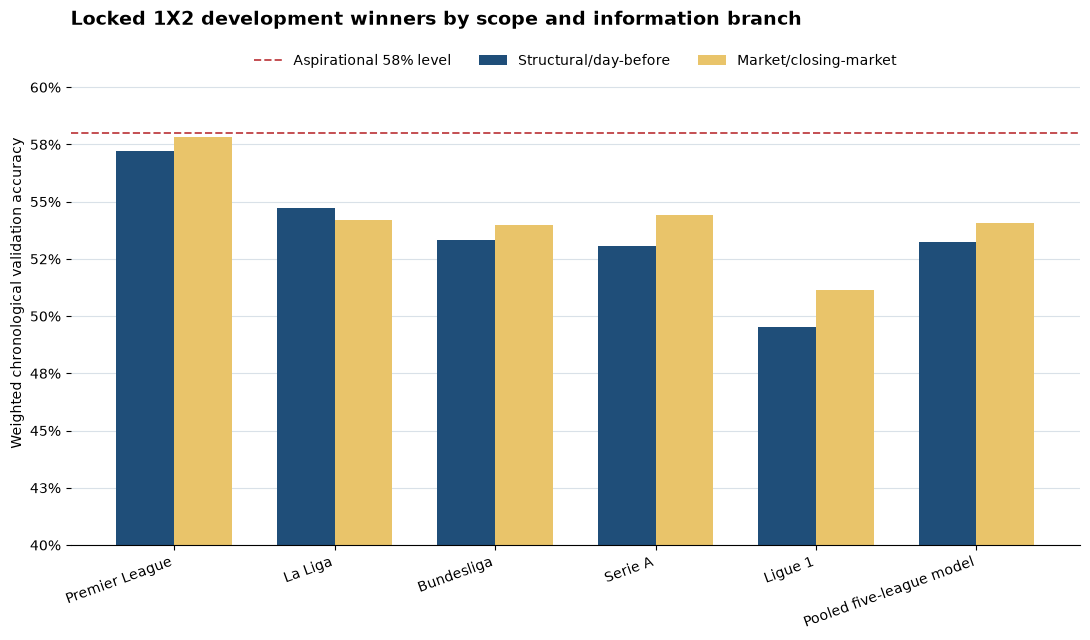

In [14]:
plot_registry = final_model_registry.copy()
plot_registry["branch_label"] = plot_registry["branch"].map({"structural": "Structural", "market": "Market"})
pivot = plot_registry.pivot(index="scope", columns="branch_label", values="accuracy").reindex([name for _, name in SCOPES])

fig, ax = plt.subplots(figsize=(11, 6.5))
x = np.arange(len(pivot))
width = 0.36
ax.bar(x - width / 2, pivot["Structural"], width, label="Structural/day-before", color="#1F4E79")
ax.bar(x + width / 2, pivot["Market"], width, label="Market/closing-market", color="#E9C46A")
ax.axhline(0.58, color="#C44E52", linestyle="--", linewidth=1.4, label="Aspirational 58% level")
ax.set_xticks(x, pivot.index, rotation=20, ha="right")
ax.set_ylim(0.40, max(0.62, float(np.nanmax(pivot.to_numpy())) + 0.025))
ax.yaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
ax.set_ylabel("Weighted chronological validation accuracy")
ax.set_title("Locked 1X2 development winners by scope and information branch", loc="left", fontsize=14, fontweight="bold", pad=12)
ax.grid(axis="y", color="#D9E1E8", linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False, ncol=3, loc="upper center")
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()

The comparison directly answers whether pooling and market information help under the same time design. Differences between the structural and market branches should be interpreted together with their different information cut-offs.

## 13. Exact features entering every final model

The registry below expands each winning branch to one row per input variable. It states the selected algorithm, hyperparameters, development estimate, feature role, source, calculation, and information cut-off. These definitions are the inputs to the locked 2024/25 walk-forward evaluation.

In [15]:
registry_feature_rows = []
for winner in final_model_registry.itertuples(index=False):
    selected = final_features[(winner.scope_code, winner.branch)]
    selected_audit = final_selection_audit.loc[
        final_selection_audit["scope"].eq(winner.scope)
        & final_selection_audit["branch"].eq(winner.branch)
        & final_selection_audit["feature"].isin(selected)
    ].set_index("feature")
    for position, feature in enumerate(selected, start=1):
        audit_row = selected_audit.loc[feature]
        registry_feature_rows.append(
            {
                "scope": winner.scope,
                "branch": winner.branch,
                "algorithm": winner.model_label,
                "hyperparameters": winner.parameters,
                "development_accuracy": winner.accuracy,
                "position": position,
                "feature": feature,
                "selection_role": audit_row["final_role"],
                "source": audit_row["source"],
                "calculation": audit_row["calculation"],
                "information_cutoff": audit_row["information_cutoff"],
            }
        )

final_feature_registry = pd.DataFrame(registry_feature_rows)
final_feature_registry.style.format({"development_accuracy": "{:.2%}"})

,scope,branch,algorithm,hyperparameters,development_accuracy,position,feature,selection_role,source,calculation,information_cutoff
0,Bundesliga,market,Equal-weight top-three ensemble,"[{'model': 'knn', 'model_label': 'k-nearest neighbours', 'parameter_id': 3, 'parameters': ""{'n_neighbors': 100, 'weights': 'distance'}""}, {'model': 'logistic', 'model_label': 'Multinomial logistic regression', 'parameter_id': 1, 'parameters': ""{'C': 0.01}""}, {'model': 'svm', 'model_label': 'Calibrated linear support vector machine', 'parameter_id': 1, 'parameters': ""{'C': 0.01}""}]",53.99%,1,elo_diff_pre,mandatory core,Calculated from Understat results,Pre-match internal Elo state,Before current result update
1,Bundesliga,market,Equal-weight top-three ensemble,"[{'model': 'knn', 'model_label': 'k-nearest neighbours', 'parameter_id': 3, 'parameters': ""{'n_neighbors': 100, 'weights': 'distance'}""}, {'model': 'logistic', 'model_label': 'Multinomial logistic regression', 'parameter_id': 1, 'parameters': ""{'C': 0.01}""}, {'model': 'svm', 'model_label': 'Calibrated linear support vector machine', 'parameter_id': 1, 'parameters': ""{'C': 0.01}""}]",53.99%,2,clubelo_diff,mandatory core,ClubElo,"Dated rating level, contrast, expectation, or availability",Valid rating interval on match date
2,Bundesliga,market,Equal-weight top-three ensemble,"[{'model': 'knn', 'model_label': 'k-nearest neighbours', 'parameter_id': 3, 'parameters': ""{'n_neighbors': 100, 'weights': 'distance'}""}, {'model': 'logistic', 'model_label': 'Multinomial logistic regression', 'parameter_id': 1, 'parameters': ""{'C': 0.01}""}, {'model': 'svm', 'model_label': 'Calibrated linear support vector machine', 'parameter_id': 1, 'parameters': ""{'C': 0.01}""}]",53.99%,3,clubelo_available,mandatory core,ClubElo,"Dated rating level, contrast, expectation, or availability",Valid rating interval on match date
3,Bundesliga,market,Equal-weight top-three ensemble,"[{'model': 'knn', 'model_label': 'k-nearest neighbours', 'parameter_id': 3, 'parameters': ""{'n_neighbors': 100, 'weights': 'distance'}""}, {'model': 'logistic', 'model_label': 'Multinomial logistic regression', 'parameter_id': 1, 'parameters': ""{'C': 0.01}""}, {'model': 'svm', 'model_label': 'Calibrated linear support vector machine', 'parameter_id': 1, 'parameters': ""{'C': 0.01}""}]",53.99%,4,diff_sofifa_top11_overall,mandatory core,Public EA Sports player data,"Dated squad aggregate, contrast, age, or availability",Latest snapshot not after match date
4,Bundesliga,market,Equal-weight top-three ensemble,"[{'model': 'knn', 'model_label': 'k-nearest neighbours', 'parameter_id': 3, 'parameters': ""{'n_neighbors': 100, 'weights': 'distance'}""}, {'model': 'logistic', 'model_label': 'Multinomial logistic regression', 'parameter_id': 1, 'parameters': ""{'C': 0.01}""}, {'model': 'svm', 'model_label': 'Calibrated linear support vector machine', 'parameter_id': 1, 'parameters': ""{'C': 0.01}""}]",53.99%,5,sofifa_available,mandatory core,Public EA Sports player data,"Dated squad aggregate, contrast, age, or availability",Latest snapshot not after match date
5,Bundesliga,market,Equal-weight top-three ensemble,"[{'model': 'knn', 'model_label': 'k-nearest neighbours', 'parameter_id': 3, 'parameters': ""{'n_neighbors': 100, 'weights': 'distance'}""}, {'model': 'logistic', 'model_label': 'Multinomial logistic regression', 'parameter_id': 1, 'parameters': ""{'C': 0.01}""}, {'model': 'svm', 'model_label': 'Calibrated linear support vector machine', 'parameter_id': 1, 'parameters': ""{'C': 0.01}""}]",53.99%,6,diff_xg_diff_ewm_span_5,mandatory core,Understat history / project calculation,Shifted exponentially weighted mean,Earlier completed matches only
6,Bundesliga,market,Equal-weight top-three ensemble,"[{'model': 'knn', 'model_label': 'k-nearest neighbours', 'parameter_id': 3, 'parameters': ""{'n_neighbors': 100, 'weights': 'distance'}""}, {'model': 'logistic', 'model_label': 'Multinomial logistic regression', 'parameter_id': 1, 'parameters':

This table is the definitive answer to “which features enter the final 1X2 models?”. No market feature appears in a structural branch, and `league_id` appears only in pooled models.

## 14. Conclusion

Feature selection and tuning are complete for all five leagues and the pooled comparison, separately for structural and market information. Every decision used the 2022/23 and 2023/24 validation seasons only. The exact candidates, rejection reasons, stability, algorithms, hyperparameters, and final feature inputs remain visible in this executed notebook.

Notebook 04 next derives the independent double-Poisson score model. It uses the notation of the thesis, estimates interpretable attack and defence parameters, converts score probabilities to 1X2 and home-win probabilities, and supplies the Poisson benchmark required by the classification comparisons.